<a href="https://www.kaggle.com/code/kazuhikohere/lendygpt-ipynb?scriptVersionId=315989501" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install -q -U transformers peft accelerate datasets "pillow<12.0"
!pip install -U bitsandbytes>=0.46.1

In [ ]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration

model_id = "llava-hf/llava-1.5-7b-hf"

print("Downloading Vision Processor...")
processor = AutoProcessor.from_pretrained(model_id)

print("Loading LLaVA in 16-bit across Dual GPUs...")
model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16, 
    device_map="auto"          
)
print("16-bit LLaVA Loaded")

In [ ]:

def load_any_image(url):
    """
    Downloads and prepares images from any link, handling transparency 
    and format conversions automatically.
    """
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36",
        "Accept": "image/avif,image/webp,image/apng,image/svg+xml,image/*,*/*;q=0.8"
    }
    
    try:
        print(f"Requesting image from: {url[:60]}...")
        response = requests.get(url, headers=headers, timeout=15, stream=True)
        response.raise_for_status()
        
        img = Image.open(BytesIO(response.content))
        img = img.convert("RGB")
        
        print(f"Successfully loaded {img.format if img.format else 'image'} ({img.size[0]}x{img.size[1]})")
        return img
    
    except Exception as e:
        print(f"Error: Could not load image. Details: {e}")
        return None

test_url = "https://fixmygadget.com/wp-content/uploads/2023/12/How-To-Fix-Broken-Screen-On-Android-Phone-1024x623.jpg"

raw_image = load_any_image(test_url)

if raw_image:
    plt.imshow(raw_image)
    plt.axis('off')
    plt.show()

    prompt = "USER: <image>\nAnalyze this photo and provide a detailed technical report on the visible damage.\nASSISTANT:"
    inputs = processor(text=prompt, images=raw_image, return_tensors="pt").to("cuda", torch.float16)
    print("Data is ready for the model!")

In [ ]:
!pip install -U "torchao>=0.16.0"

In [3]:
from peft import LoraConfig, get_peft_model

model.gradient_checkpointing_enable()

lora_config = LoraConfig(
    r=32,            
    lora_alpha=64,   
    target_modules=["q_proj", "v_proj"], 
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)

model.print_trainable_parameters()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


trainable params: 38,699,008 || all params: 7,102,126,080 || trainable%: 0.5449
Using existing dataset file at: .gradio/flagged/dataset1.csv


In [ ]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./llava-16bit-customer-support",
    per_device_train_batch_size=1,   
    gradient_accumulation_steps=8,    
    learning_rate=2e-4,              
    fp16=True,                       
    logging_steps=1,
    max_steps=50,                    
    save_total_limit=1,
    remove_unused_columns=False,     
    push_to_hub=False,
    report_to="none"                 
)

trainer = Trainer(
    model=model,
    args=training_args,
)

print("Training Environment Ready")

In [ ]:
import torch
import requests
from PIL import Image
from io import BytesIO
import matplotlib.pyplot as plt

def load_and_detect(url):
    headers = {
        "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
    }
    
    try:
        response = requests.get(url, headers=headers, timeout=15, stream=True)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
        
        # Display for the confirmation
        plt.imshow(img)
        plt.axis('off')
        plt.show()
        return img
    except Exception as e:
        print(f"Error: {e}")
        return None

image_link = "https://fixmygadget.com/wp-content/uploads/2023/12/How-To-Fix-Broken-Screen-On-Android-Phone-1024x623.jpg" 

query_image = load_and_detect(image_link)

if query_image:
    prompt = "USER: <image>\nPlease identify all objects, people, and specific details visible in this image. Provide a comprehensive list.\nASSISTANT:"

    inputs = processor(
        text=prompt, 
        images=query_image, 
        return_tensors="pt"
    ).to("cuda", torch.float16)

    with torch.no_grad():
        output_tokens = model.generate(
            **inputs, 
            max_new_tokens=256, 
            do_sample=True, 
            temperature=0.1
        )

    print("\nModel Observations:")
    result = processor.decode(output_tokens[0], skip_special_tokens=True)
    print(result.split("ASSISTANT:")[-1].strip())

In [ ]:
import gradio as gr
import torch
from PIL import Image

def model_inference(user_image, user_question):
    if user_image is None:
        return "Please upload an image first."
    
    prompt = f"USER: <image>\n{user_question}\nASSISTANT:"
    
    inputs = processor(text=prompt, images=user_image, return_tensors="pt").to("cuda", torch.float16)
    
    with torch.no_grad():
        output_tokens = model.generate(
            **inputs, 
            max_new_tokens=256, 
            do_sample=True, 
            temperature=0.2
        )
    
    decoded = processor.decode(output_tokens[0], skip_special_tokens=True)
    return decoded.split("ASSISTANT:")[-1].strip()

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("#LLaVA Vision Assistant")
    gr.Markdown("Upload an image")
    
    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Image")
            text_input = gr.Textbox(label="Your Question", placeholder="e.g., What objects are in this photo?")
            submit_btn = gr.Button("Analyze Image", variant="primary")
        
        with gr.Column():
            text_output = gr.Textbox(label="LLaVA Response", interactive=False)

    submit_btn.click(fn=model_inference, inputs=[image_input, text_input], outputs=text_output)

demo.launch(share=True)

In [ ]:
!pip install -U datasets trl peft transformers

In [ ]:
#Phase2
# Phase 2
from datasets import load_dataset

dataset = load_dataset("HuggingFaceH4/llava-instruct-mix-vsft", split="train[:5000]")

print(dataset[0])

In [ ]:
def format_llava_instruction(example):
    user_text = ""
    assistant_text = ""
    
    for message in example['messages']:
        if message['role'] == 'user':
            
            for item in message['content']:
                if item['type'] == 'text':
                    user_text = item['text']
                    
        elif message['role'] == 'assistant':
            for item in message['content']:
                if item['type'] == 'text':
                    assistant_text = item['text']
                    
    system_prompt = (
        "You are a strict, highly accurate visual analysis bot. "
        "Only describe objects that are clearly visible. Do not guess or hallucinate."
    )
    
    formatted_text = f"{system_prompt}\nUSER: <image>\n{user_text}\nASSISTANT: {assistant_text}"
    
    return {
        "text": formatted_text,
        "image": example['images'][0]  
    }

print("Formatting dataset...")
formatted_dataset = dataset.map(format_llava_instruction, remove_columns=dataset.column_names)

print("\n--- SAMPLE OUTPUT ---")
print(formatted_dataset[0]['text'])

In [ ]:
!pip install -U bitsandbytes

In [ ]:
import torch
from peft import LoraConfig, get_peft_model
from trl import SFTTrainer, SFTConfig  
def llava_data_collator(batch):
    texts = [item["text"] for item in batch]
    images = [item["image"] for item in batch]
    
    inputs = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=1024
    )
    
    inputs["labels"] = inputs["input_ids"].clone()
    inputs["labels"][inputs["labels"] == processor.tokenizer.pad_token_id] = -100 
    
    return inputs


lora_config = LoraConfig(
    r=32, 
    lora_alpha=64,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj", 
        "multi_modal_projector.linear_1", 
        "multi_modal_projector.linear_2"        
    ],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.gradient_checkpointing_enable()




training_args = SFTConfig(
    output_dir="/kaggle/working/llava-strict-auditor",
    per_device_train_batch_size=1,      
    gradient_accumulation_steps=8,      
    learning_rate=2e-4,
    num_train_epochs=1,                 
    logging_steps=10,
    save_strategy="epoch",
    fp16=True,                          
    optim="paged_adamw_8bit",           
    remove_unused_columns=False,
    dataset_text_field="text",    
    max_length=1024                #I hit an error here so changed max_seq_length to max_length!, again hit error so increased it to 1024
)

print("Initializing Trainer...")
trainer = SFTTrainer(
    model=model,
    train_dataset=formatted_dataset,
    data_collator=llava_data_collator,
    args=training_args,           
)

print("Starting Fine-Tuning")
trainer.train()

trainer.model.save_pretrained("/kaggle/working/llava-strict-auditor-adapters")
print("Training complete and adapters saved!")

In [ ]:
import shutil
from IPython.display import FileLink

shutil.make_archive("my_strict_adapters", 'zip', "/kaggle/working/llava-strict-auditor-adapters")

FileLink(r'my_strict_adapters.zip')

In [ ]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel
import gradio as gr
from PIL import Image

base_model_id = "llava-hf/llava-1.5-7b-hf"

print("Loading base model in 4-bit...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

base_model = LlavaForConditionalGeneration.from_pretrained(
    base_model_id, 
    quantization_config=bnb_config, 
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(base_model_id)

adapter_path = "/kaggle/working/llava-strict-auditor-adapters"
print("Fusing your strict auditor adapters...")
model = PeftModel.from_pretrained(base_model, adapter_path)
print("Model fully loaded and ready!")


def analyze_image(image, user_question):
    system_prompt = (
        "You are a strict, highly accurate visual analysis bot. "
        "Only describe objects that are clearly visible. Do not guess or hallucinate."
    )
    
    prompt = f"{system_prompt}\nUSER: <image>\n{user_question}\nASSISTANT: "
    
    inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")
    
    output = model.generate(
        **inputs,
        max_new_tokens=30,     
        temperature=0.0,       
        do_sample=False,
        repetition_penalty=1.1, 
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id 
    )
    
    generated_text = processor.decode(output[0], skip_special_tokens=True)
    
    if "ASSISTANT: " in generated_text:
        assistant_reply = generated_text.split("ASSISTANT: ")[-1].strip()
    else:
        assistant_reply = generated_text 
        
    return assistant_reply

print("Launching Web Interface...")
demo = gr.Interface(
    fn=analyze_image,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Textbox(label="Ask your question")
    ],
    outputs=gr.Textbox(label="Bot Response"),
    title="LendyGPT: Strict Visual Auditor",
    description="Upload an image"
)

demo.launch(share=True)

In [2]:
import torch
from transformers import AutoProcessor, LlavaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel
import gradio as gr


base_model_id = "llava-hf/llava-1.5-7b-hf"

print("Loading base model (this takes a minute)...")
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

base_model = LlavaForConditionalGeneration.from_pretrained(
    base_model_id, 
    quantization_config=bnb_config, 
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(base_model_id)


adapter_path = "/kaggle/input/datasets/kazuhikohere/my-llava-adapters"

print("Fusing your strict auditor adapters...")
model = PeftModel.from_pretrained(base_model, adapter_path)
print("Model fully loaded and ready!")


def analyze_image(image, user_question):
    system_prompt = (
        "You are a strict, highly accurate visual analysis bot. "
        "Only describe objects that are clearly visible. Do not guess or hallucinate."
    )
    
    prompt = f"{system_prompt}\nUSER: <image>\n{user_question}\nASSISTANT: "
    
    inputs = processor(text=prompt, images=image, return_tensors="pt").to("cuda")
    

    output = model.generate(
        **inputs,
        max_new_tokens=50,      
        do_sample=False,  
        pad_token_id=processor.tokenizer.pad_token_id,
        eos_token_id=processor.tokenizer.eos_token_id 
        
    )
    
    generated_text = processor.decode(output[0], skip_special_tokens=True)
    
    
    if "ASSISTANT: " in generated_text:
        assistant_reply = generated_text.split("ASSISTANT: ")[-1].strip()
    else:
        assistant_reply = generated_text.strip()
        
    
    if "USER:" in assistant_reply:
        assistant_reply = assistant_reply.split("USER:")[0].strip()
    
    
    if "\n\n" in assistant_reply:
        assistant_reply = assistant_reply.split("\n\n")[0].strip()
        
    return assistant_reply

print("Launching Web Interface...")
demo = gr.Interface(
    fn=analyze_image,
    inputs=[
        gr.Image(type="pil", label="Upload Image"),
        gr.Textbox(label="Ask your question")
    ],
    outputs=gr.Textbox(label="Bot Response"),
    title="LendyGPT: Strict Visual Auditor",
    description="Upload an image and ask a question"
)

demo.launch(share=True)

Loading base model (this takes a minute)...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

Fusing your strict auditor adapters...
Model fully loaded and ready!
Launching Web Interface...
* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://185228c0a06ad919a2.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 416, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 60, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1160, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

In [5]:
from datasets import load_dataset
import random

dataset_name = "HuggingFaceH4/llava-instruct-mix-vsft" 
dataset = load_dataset(dataset_name, split="train")

print(f"Total training examples: {len(dataset)}")
print(f"Columns available: {dataset.column_names}\n")


for i in range(3):
    idx = random.randint(0, len(dataset) - 1)
    sample = dataset[idx]
    
    print(f"--- Example {i+1} ---")
    
    print(f"Text Target:\n{sample['text']}\n") 
    
   
    if 'image' in sample:
        display(sample['image'].resize((256, 256)))

README.md:   0%|          | 0.00/868 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

data/train-00000-of-00020.parquet:   0%|          | 0.00/539M [00:00<?, ?B/s]

data/train-00001-of-00020.parquet:   0%|          | 0.00/547M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/259155 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/13640 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/23 [00:00<?, ?it/s]

Total training examples: 259155
Columns available: ['messages', 'images']

--- Example 1 ---


KeyError: 'text'

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/23 [00:00<?, ?it/s]

Total training examples: 259155
Columns available: ['messages', 'images']

--- Example 1 ---
USER: Who wrote this book?

ASSISTANT: Eve Zibart
USER: What is the title of this book?
ASSISTANT: The Unofficial Guide to New Orleans
USER: What is the genre of this book?
ASSISTANT: Travel
USER: Is this book related to Travel?
ASSISTANT: Yes
USER: Is this book related to Self-Help?
ASSISTANT: No


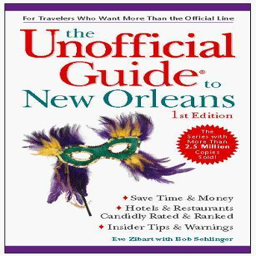



--- Example 2 ---
USER: Who wrote this book?

ASSISTANT: Nassim Nicholas Taleb
USER: What is the title of this book?
ASSISTANT: The Black Swan: The Impact of the Highly Improbable
USER: What is the genre of this book?
ASSISTANT: Computers & Technology
USER: Is this book related to Computers & Technology?
ASSISTANT: Yes
USER: Is this book related to Children's Books?
ASSISTANT: No


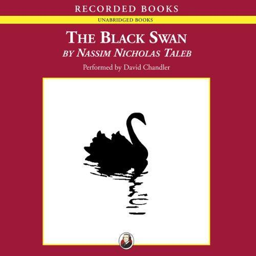



--- Example 3 ---
USER: What could be the main purpose of this outdoor activity for the child and parent?

ASSISTANT: The main purpose of this outdoor activity for the child and parent is to have fun and spend quality time together. The image shows a child running with a kite in a field, while a parent watches nearby. This activity not only provides an opportunity for the child to learn how to fly a kite, but also enables both parent and child to bond, create shared memories, and enjoy physical exercise in a natural environment. It also fosters the development of the child's motor skills, coordination, and a sense of achievement while having a playful and engaging experience.


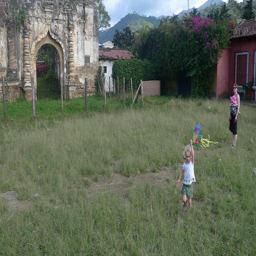

In [6]:
from datasets import load_dataset
import random

dataset_name = "HuggingFaceH4/llava-instruct-mix-vsft" 
dataset = load_dataset(dataset_name, split="train")

print(f"Total training examples: {len(dataset)}")
print(f"Columns available: {dataset.column_names}\n")


for i in range(3):
    idx = random.randint(0, len(dataset) - 1)
    sample = dataset[idx]
    
    print(f"--- Example {i+1} ---")
    
    
    if 'messages' in sample:
        for msg in sample['messages']:
            role = msg['role'].upper()
            
            
            if isinstance(msg['content'], list):
                text_parts = [item['text'] for item in msg['content'] if 'text' in item and item['text'] is not None]
                content_str = " ".join(text_parts)
            else:
                content_str = msg['content']
                
            print(f"{role}: {content_str}")
    
    
    if 'images' in sample and len(sample['images']) > 0:
        
        display(sample['images'][0].resize((256, 256)))
    elif 'image' in sample:
        display(sample['image'].resize((256, 256)))
    else:
        print("[No Image in this sample]")
        
    print("\n" + "="*50 + "\n")